### Imports

In [1]:
import sys
sys.path.append("..")

import os
import dill
import json
import torch
import string
import warnings
import functools
import itertools
import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

from cdt.metrics import SHD
from sklearn.metrics import roc_auc_score

from tempogen.functional_utils import (_torch_sin, _torch_cos,_torch_gelu, _torch_softplus,
                                       _torch_sigmoid, _torch_identity, _torch_sqrt)
from tempogen.generate_synthetic_data import check_identifiability
from simulation.simulation_tools import get_optimal_sim_XYP
from simulation.simulation_metrics import run_detection_metrics
from utils import check_non_stationarity, print_time_slices
from tempogen.temporal_scm import TempSCM

def prind(di): print(json.dumps(di, sort_keys=False, indent=4))

COL_NAMES = list(string.ascii_uppercase) + ["".join(a) for a in list(itertools.permutations(list(string.ascii_uppercase), r=2))]


""" _______________ Parameters _______________ """

# paths
par_dir = Path(os.getcwd()).parents[1].as_posix()
archive_path = Path(par_dir) / 'data' / 'results' / 'archive' / 'archive_interventions'

# parameters
FN = "sid"
SF = "NL_10V_1L"
NS = 1000
N_SCMS = 30
FNS = 1
IPR = range(int(0.5*NS), int(0.75*NS), 1)
LOC = 0.0
SCALE = 1.5
SEED = 1234

# utility functions
# minimal adjacency
def minimal_adjacency(adj):
    i2k = list(range(adj.shape[2]))
    for k in range(adj.shape[2]):
        if adj[:, :, k].sum()==0:
            i2k.remove(k)
        else:
            break
    return adj[:, :, i2k]

# plot adjacency matrix
def plot_adjacency(
        adj, 
        size=6,
        circle_outline_color="black",
        circle_fill_color="white", 
        edge_colors={}
):
    """ """
    # parameters
    figsize = [size, size] 
    n_vars = adj.shape[0]
    n_lags = adj.shape[2]
    circle_radius = 1/(3*n_vars - 1)
    circle_outline_color = "black"
    circle_fill_color = "white"
    fontsize = circle_radius * size * 30

    # x-positions
    x_incr = (1-(circle_radius*3)) / (n_lags)
    x_positions = {lag: circle_radius*(3/2) + x_incr*lag for lag in range(n_lags + 1)}

    # y-positions
    y_incr = (1-(circle_radius*3)) / (n_vars-1)
    y_positions = {var: 1 - (circle_radius*(3/2) + y_incr*var) for var in range(n_vars)}

    # node names
    node_names = {lag: ["_".join([x, "{"+"t"+"}"]) if lag==n_lags else "_".join([x, "{"+f"t-{n_lags-lag}"+"}"]) 
                        for x in COL_NAMES[:n_vars]] for lag in range(n_lags+1)}

    # plot
    f, ax = plt.subplots(figsize=figsize)

    # node loop 
    for k in range(n_lags + 1):
        for i in range(n_vars):
            # Add circles to the plot
            xy = (x_positions[k], y_positions[i])
            circle1 = mpatches.Circle(xy=xy, radius=circle_radius, color=circle_fill_color, ec=circle_outline_color, zorder=3)
            ax.add_patch(circle1)
            ax.annotate(f"${node_names[k][i]}$", xy=xy, fontsize=fontsize, va='center', ha='center')

    # edge loop
    for k in range(n_lags): 
        for i in range(n_vars):
            for j in range(n_vars):
                if adj[i, j, k] == 1:
                    # draw edge
                    xy_source = (x_positions[k] + circle_radius, y_positions[j]) # source : B_t-2
                    xy_target = (x_positions[adj.shape[2]] - circle_radius, y_positions[i]) # target : A_t
                    arrow = mpatches.FancyArrowPatch(
                        posA=xy_source,       
                        posB=xy_target,       
                        shrinkA=1.5,  
                        shrinkB=2.5,  
                        linewidth=0.8,
                        arrowstyle="-|>",     
                        mutation_scale=10,
                        connectionstyle="arc3",
                        color=edge_colors[(i, j, k)] if (i, j, k) in edge_colors.keys() else "black",
                        # color='darkred',
                        alpha=1,
                        zorder=2
                    )
                    ax.add_patch(arrow)

    # limits and aspect ratio
    ax.set_xticks([], [])
    ax.set_yticks([], [])
    ax.axis("off")
    ax.set_aspect('equal', adjustable='datalim')

    # show
    plt.show()

# check data validity under the assumptions
def check_data_validity(data):
    try:
        assert not check_non_stationarity(data), "ValueError: Generated data contain non-stationary time-series."
        assert check_identifiability(data), "ValueError: Graph may not be identified from the generated data."
        return True
    except Exception as e:
        print(f"LOG: Exception: {e}")
        return False

# fix lag dimensions
def fix_lag_dim(a_graph, b_graph):
    if  a_graph.shape[2]>b_graph.shape[2]:
        b_graph = torch.nn.functional.pad(input=b_graph, pad=(a_graph.shape[2] - b_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    if  b_graph.shape[2]>a_graph.shape[2]:
        a_graph = torch.nn.functional.pad(input=a_graph, pad=(b_graph.shape[2] - a_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    return a_graph, b_graph

# intervening functions
# functools.partial(_torch_noisy_f, func=true_scm_i.temp_nodes[n2i].func)
def _torch_noisy_f(x, loc=0, scale=0.05, func=_torch_identity):
    """ """
    noise_dist = torch.distributions.normal.Normal(loc=loc, scale=scale)
    return func(x) + noise_dist.sample()

Detecting 1 CUDA device(s).


 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)].


### Data Generation

In [ ]:
# # vars space
n_vars_space = {
    "vars": [10],
    "weights": [1] 
}

# # lags space
n_lags_space = {
    "lags": [1],
    "weights": [1]
}

# in-degree space
in_degree_space = {
    "degrees": [1],
    "weights": [1]
}

# funcs space
funcs_space = {
    "funcs": [_torch_identity, _torch_sqrt, _torch_sigmoid, _torch_cos],
    "weights": [0.80, 0.20, 0.00, 0.00,]
}

# noise space
z_distribution_space = {
    "dists": [torch.distributions.Normal(loc=0, scale=0.05)],
    "weights": [1.0]
}

# generate valid TSCMs
i = 0
data_list = []
for ctr in range(N_SCMS):

    data_sum = len(data_list)
    while len(data_list)==data_sum:
            
        try:    
            rng = np.random.default_rng(seed=ctr + i)

            # sample a random TSCM (ground-truth causal model)
            n_lags = rng.choice(n_lags_space["lags"], p=n_lags_space["weights"])
            n_vars = rng.choice(n_vars_space["vars"], p=n_vars_space["weights"])
            i_degree = rng.choice(in_degree_space["degrees"], p=in_degree_space["weights"])
            funcs = [rng.choice(funcs_space["funcs"], p=funcs_space["weights"]) for _ in range(n_vars)]
            z_distributions = [rng.choice(z_distribution_space["dists"], p=z_distribution_space["weights"]) for _ in range(n_vars)]
            tscm = TempSCM(
                method="ID",
                n_vars=n_vars,
                n_lags=n_lags,
                i_degree=i_degree,
                funcs=funcs,
                z_distributions=z_distributions
            )
            data = tscm.generate_time_series(n_samples=NS)
            tscm._reset_time_series()
            if check_data_validity(data):
                data_list.append({"tscm": tscm})
                print(f"- LOG: # valid TSCMs: {len(data_list)}")
            else:
                i += 1
        except:
            i += 1

### Apply ACT

In [ ]:
for idx, item in enumerate(data_list):
    
    scm_ori = deepcopy(item["tscm"])
    
    # generate observational
    ts_pre = scm_ori.generate_time_series(n_samples=NS).reset_index(drop=True)

    # learn the TSCM with ACT
    data_ori = ts_pre.copy()
    act_res = get_optimal_sim_XYP(true_data=data_ori, sparsity_penalty=True, init=True)
    scm_sim = act_res['optimal_scm']

    ori_graph, sim_graph = fix_lag_dim(
        a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
        b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
    )
    shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())
    print(f"\n - LOG: SHD: {shd} \n")

    # save original TSCM
    with open(archive_path / 'tscm_extra' / 'ori' / f'sid_tscm_ori_{idx}.dill.', "wb") as f:
        archive = dill.dump(scm_ori, f)

    # save simulated TSCM
    with open(archive_path / 'tscm_extra' / 'sim' / f'sid_tscm_sim_{idx}.dill.', "wb") as f:
        archive = dill.dump(scm_sim, f)

#### Multiple Runs

In [ ]:
for idx, (fn_ori, fn_sim) in enumerate(list(zip(
    os.listdir(archive_path / "tscm" / "ori"), 
    os.listdir(archive_path / "tscm" / "sim")
))[:]):
    print(f" ------------------------ {idx} ------------------------ ")

    # loop
    for sf in ["sim_1", "sim_2"]:

        # read original and simulated TSCMs
        with open(archive_path / "tscm" / "ori" / fn_ori, "rb") as f_ori:
            scm_ori = dill.load(f_ori)

        # learn the TSCM with ACT
        data_ori = scm_ori.time_series.copy()
        act_res = get_optimal_sim_XYP(true_data=data_ori, sparsity_penalty=True, init=True)
        scm_sim = act_res['optimal_scm']

        # shd
        ori_graph, sim_graph = fix_lag_dim(
            a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
            b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
        )
        shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())
        print(f"\n - LOG: SHD: {shd} \n")

        # save simulated TSCM
        os.makedirs(archive_path / 'tscm' / sf, exist_ok=True)
        with open(archive_path / 'tscm' / sf / f'sid_tscm_sim_{idx}.dill.', "wb") as f:
            archive = dill.dump(scm_sim, f)

### Run Experiments

#### Single Run

In [ ]:
toi_list = []
n2i_list = [] 
data_list_obs = []
data_list_int = []
res_df = pd.DataFrame(columns=["auc_do", "auc_di", "shd", "auc_c"])

for idx, (fn_ori, fn_sim) in enumerate(list(zip(
    os.listdir(archive_path / "tscm" / "ori"), 
    os.listdir(archive_path / "tscm" / "sim")
    ))[:] + list(zip(
    os.listdir(archive_path / "tscm_extra" / "ori"), 
    os.listdir(archive_path / "tscm_extra" / "sim")
))[:]):
    print(f" ------------------------ {idx} ------------------------ ")
    
    # read original and simulated TSCMs
    with open(archive_path / "tscm_extra" / "ori" / fn_ori, "rb") as f_ori:
        scm_ori = dill.load(f_ori)
    with open(archive_path / "tscm_extra" / "sim" / fn_sim, "rb") as f_sim:
        scm_sim = dill.load(f_sim)

    # shd
    ori_graph, sim_graph = fix_lag_dim(
        a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
        b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
    )
    shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())
    auc_c = roc_auc_score(y_true=ori_graph.flatten().numpy(), y_score=sim_graph.flatten().numpy())

    # observational data
    scm_ori._reset_time_series(init_history=scm_ori.time_series.loc[:3, :]) # NOTE: 3 is the maximum supported lag in the configuration search space
    scm_sim._reset_time_series(init_history=scm_ori.time_series.loc[:3, :])
    scm_ori.generate_time_series(n_samples=NS)
    scm_sim.generate_time_series(n_samples=NS)
    ts_ori_obs = scm_ori.time_series.copy()
    ts_sim_obs = scm_sim.time_series.copy()

    # time of intervention & pre-intervention data
    toi = np.random.randint(low=int(0.50 * NS), high=int(0.51 * NS))
    ts_ori_pre = scm_ori.time_series.loc[:toi, :].copy()
    ts_sim_pre = scm_sim.time_series.loc[:toi, :].copy()

    # pre-intervention data & intervening nodes and values
    scm_ori.time_series = ts_ori_pre.copy()
    scm_sim.time_series = ts_sim_pre.copy() # NOTE: should scm_sim be initialized with the same values?
    n2is = np.random.choice(a=range(len(scm_ori.temp_nodes)), size=FNS, replace=False)
    for n2i in n2is:
        s2i = scm_ori.time_series.iloc[:, n2i]
        assert s2i.min()!=s2i.max(), f"ValueError: constant column {n2i}."
        # hard-intervention with constant value
        scm_ori.temp_nodes[n2i].func = lambda x: s2i.min()
        scm_sim.temp_nodes[n2i].func = lambda x: s2i.min() # NOTE: intervening with the same value 
        scm_ori.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)
        scm_sim.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)

    # post-intervention & interventional data 
    ts_ori_int = scm_ori.generate_time_series(n_samples=NS-toi).copy()
    ts_sim_int = scm_sim.generate_time_series(n_samples=NS-toi + 1).copy() # NOTE: +1 needed but why?
    ts_ori_post = scm_ori.time_series.loc[toi:, :].copy()
    ts_sim_post = scm_sim.time_series.loc[toi:, :].copy()

    # monitoring
    toi_list.append(toi)
    n2i_list.append(n2i)
    data_list_obs.append([ts_ori_obs, ts_sim_obs])
    data_list_int.append([ts_ori_int, ts_sim_int])

    """"  --------------------------------------------------------------------------------------------  """
    
    # evaluate
    auc_d_obs = run_detection_metrics(real=ts_ori_obs, synthetic=ts_sim_obs)["auc"]
    print(f"LOG: Discrimination AUC on observational data: {auc_d_obs}")
    auc_d_int = run_detection_metrics(real=ts_ori_int, synthetic=ts_sim_int)["auc"]
    print(f"LOG: Discrimination AUC on interventional data: {auc_d_int}")
    res_df.loc[idx] = [auc_d_obs, auc_d_int, shd, auc_c]
    print()

# res_df.to_csv(archive_path / 'misc' / 'w_auc_c' / 'res_df_r0.csv', index=False)

#### Multiple Runs

In [ ]:
toi_list = {}
n2i_list = {} 
auc_list_obs = {}
auc_list_int = {}
data_list_obs = {}
data_list_int = {}
res_df = pd.DataFrame(columns=["auc_do", "auc_di", "shd"])

for idx, (fn_ori, fn_sim) in enumerate(list(zip(
    os.listdir(archive_path / "tscm" / "ori"), 
    os.listdir(archive_path / "tscm" / "sim")
))[:]):
    print(f" ------------------------ {idx} ------------------------ ")
    
    # read original and simulated TSCMs
    with open(archive_path / "tscm" / "ori" / fn_ori, "rb") as f_ori:
        scm_ori = dill.load(f_ori)
    with open(archive_path / "tscm" / "sim" / fn_sim, "rb") as f_sim:
        scm_sim = dill.load(f_sim)

    # shd
    ori_graph, sim_graph = fix_lag_dim(
        a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
        b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
    )
    shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())

    # monitoring
    toi_list[idx] = []
    n2i_list[idx] = []
    auc_list_obs[idx] = []
    auc_list_int[idx] = []
    data_list_obs[idx] = []
    data_list_int[idx] = []

    for idy in range(5):
        print(f" --- idx={idx} | idy={idy} --- ")
        
        # observational data
        scm_ori._reset_time_series(init_history=scm_ori.time_series.loc[:3, :]) # NOTE: 3 is the maximum supported lag in the configuration search space
        scm_sim._reset_time_series(init_history=scm_ori.time_series.loc[:3, :])
        scm_ori.generate_time_series(n_samples=NS)
        scm_sim.generate_time_series(n_samples=NS)
        ts_ori_obs = scm_ori.time_series.copy()
        ts_sim_obs = scm_sim.time_series.copy()

        # time of intervention & pre-intervention data
        toi = np.random.randint(low=int(0.50 * NS), high=int(0.51 * NS))
        ts_ori_pre = scm_ori.time_series.loc[:toi, :].copy()
        ts_sim_pre = scm_sim.time_series.loc[:toi, :].copy()

        # pre-intervention data & intervening nodes and values
        scm_ori.time_series = ts_ori_pre.copy()
        scm_sim.time_series = ts_sim_pre.copy() # NOTE: should scm_sim be initialized with the same values?
        n2is = np.random.choice(a=range(len(scm_ori.temp_nodes)), size=FNS, replace=False)
        for n2i in n2is:
            s2i = scm_ori.time_series.iloc[:, n2i]
            assert s2i.min()!=s2i.max(), f"ValueError: constant column {n2i}."
            # hard-intervention with constant value
            scm_ori.temp_nodes[n2i].func = lambda x: s2i.min()
            scm_sim.temp_nodes[n2i].func = lambda x: s2i.min() # NOTE: intervening with the same value 
            scm_ori.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)
            scm_sim.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)

        # post-intervention & interventional data 
        ts_ori_int = scm_ori.generate_time_series(n_samples=NS-toi).copy()
        ts_sim_int = scm_sim.generate_time_series(n_samples=NS-toi + 1).copy() # NOTE: +1 needed but why?
        ts_ori_post = scm_ori.time_series.loc[toi:, :].copy()
        ts_sim_post = scm_sim.time_series.loc[toi:, :].copy()

        # monitoring
        toi_list[idx].append(toi)
        n2i_list[idx].append(n2i)
        data_list_obs[idx].append([ts_ori_obs, ts_sim_obs])
        data_list_int[idx].append([ts_ori_int, ts_sim_int])

        """"  --------------------------------------------------------------------------------------------  """
        
        # evaluate
        auc_d_obs = run_detection_metrics(real=ts_ori_obs, synthetic=ts_sim_obs)["auc"]
        print(f"LOG: Discrimination AUC on observational data: {auc_d_obs}")
        auc_d_int = run_detection_metrics(real=ts_ori_int, synthetic=ts_sim_int)["auc"]
        print(f"LOG: Discrimination AUC on interventional data: {auc_d_int}")
        print()
        auc_list_obs[idx].append(np.round(auc_d_obs, 2))
        auc_list_int[idx].append(np.round(auc_d_int, 2))

    res_df.loc[idx] = [np.mean(auc_list_obs[idx]).round(2), np.mean(auc_list_int[idx]).round(2), shd]


### Plotting

#### Scatterplots

In [ ]:
# taken from https://matplotlib.org/stable/gallery/lines_bars_and_markers/multicolored_line.html 
def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    if len(c) != len(x) - 1:
        warnings.warn(
            "The c argument should have a length one less than the length of x and y. "
            "If it has the same length, use the colored_line function instead."
        )
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)
    lc.set_array(c)
    return ax.add_collection(lc)

# color according to AUC values
def color_switch(auc, start_color="navajowhite", end_color="indianred", n_points=10):
    cmap = LinearSegmentedColormap.from_list("mycmap", [start_color, end_color])
    endpoints = [-np.inf] + list(np.linspace(start=0.5, stop=1.0, num=n_points)[1:-1]) + [np.inf]
    intervals = [pd.Interval(left=endpoints[i], right=endpoints[i+1]) for i in range(len(endpoints)-1)]
    colors = cmap(np.linspace(0, 1, n_points-1))
    for idx, interval in enumerate(intervals):
        if auc in interval:
            color = colors[idx]
            break
    return color

# # load existing
# res_fn_list = [f"res_df_r{i}.csv" for i in range(10)]
# res_df_list = [pd.read_csv(archive_path / 'misc' / 'w_auc_c' / fn) for fn in res_fn_list]
# res_df = (sum(res_df_list) / len(res_df_list)).round(3)
# res_df.loc[:, "var"] = [np.var([abs(df.loc[i, "auc_do"] - df.loc[i, "auc_di"]) for df in res_df_list]).round(2) for i in range(20)]

# scatterplot
f, ax = plt.subplots(figsize=(12, 5))
ax.set_xticks(range(len(res_df)))
ax.set_yticks(np.arange(start=0.5, stop=1.01, step=0.1))
ax.set_ylim([0.4, 1.1])
# ax.set_xlabel("TSCM Instances", fontsize=12)
ax.set_ylabel("AUC$_{D}$", fontsize=12)
for i, (auc_do, auc_di) in enumerate(zip(res_df["auc_do"], res_df["auc_di"])):
    ax.scatter(x=i, y=auc_do, marker='o', s=110, color="navajowhite", label=r"Observational AUC$_{D}$")
    ax.scatter(x=i, y=auc_di, marker='*', s=110, color="lightcoral", label=r"Interventional AUC$_{D}$")
    ax.plot((i, i), (auc_do, auc_di), linestyle='--', color="black", alpha=0.5)
    ax.text(i, max(auc_do, auc_di) + 0.015, f"{abs(auc_do - auc_di):.2f}", ha='center', va='bottom', fontsize=8)
    # ax.text(i, max(auc_do, auc_di) + 0.015, f"{abs(auc_do - auc_di):.2f}$\pm${res_df.loc[i, 'var']}", ha='center', va='bottom', fontsize=8)
    # ax.text(i, max(auc_do, auc_di) + 0.015, f"$\Delta$={abs(auc_do - auc_di):.2f}", ha='center', va='bottom', fontsize=8)
    ax.text(i, max(auc_do, auc_di) + 0.035, f"SHD={res_df.loc[i, 'shd']:.0f}", ha='center', va='bottom', fontsize=8)

custom_lines = [Line2D([0], [0], color="navajowhite", marker="o", markersize=8, lw=2),
                Line2D([0], [0], color="lightcoral", marker="*", markersize=8, lw=2)]
ax.legend(custom_lines, ['Observational', 'Interventional'])
plt.show()

# colorful scatterplot
f, ax = plt.subplots(figsize=(14, 5))
ax.set_xticks(range(len(res_df)))
ax.set_yticks(np.arange(start=0.5, stop=1.01, step=0.1))
ax.set_ylim([0.4, 1.1])
ax.set_xlabel("TSCM Instances", fontsize=12)
ax.set_ylabel("AUC$_{D}$", fontsize=12)
for i, (auc_do, auc_di) in enumerate(zip(res_df["auc_do"], res_df["auc_di"])):
    ax.scatter(x=i, y=auc_do, marker='o', s=110, color=color_switch(auc_do), label=r"Observational AUC$_{D}$")
    ax.scatter(x=i, y=auc_di, marker='*', s=110, color=color_switch(auc_di), label=r"Interventional AUC$_{D}$")
    # ax.plot((i, i), (auc_do, auc_di), linestyle='--', color="black", alpha=0.5)
    mycmap = LinearSegmentedColormap.from_list("mycmap", [color_switch(auc_do), color_switch(auc_di)])
    colored_line_between_pts(
        x=np.full(shape=[10], fill_value=i), 
        y=np.linspace(start=auc_do, stop=auc_di, num=10), 
        c=np.linspace(0, 1, 9),
        ax=ax, cmap=mycmap, linewidth=2, linestyle='-'
    )
    ax.text(i, max(auc_do, auc_di) + 0.01, f"{abs(auc_do - auc_di):.2f}", ha='center', va='bottom', fontsize=8)

mycmap = LinearSegmentedColormap.from_list("mycmap", ['navajowhite', 'lightcoral'])
custom_lines = [Line2D([0], [0], color="w", marker="o", markersize=10, markerfacecolor='navajowhite'),
                Line2D([0], [0], color="w", marker="*", markersize=15, markerfacecolor='lightcoral')]
ax.legend(custom_lines, ['Observational', 'Interventional'])
cbar = f.colorbar(plt.cm.ScalarMappable(cmap=mycmap), ax=ax, shrink=0.6, pad=0.01)
cbar.set_label(label='AUC$_{D}$ Color Scale', labelpad=10, y=0.5)
plt.show()

# # barplot
# f, ax = plt.subplots(figsize=(15, 6))
# width = 0.4
# ax.set_xticks(range(len(res_df)))
# ax.set_yticks(np.arange(start=0.5, stop=1.01, step=0.1))
# ax.set_ylim([0.4, 1.1])
# ax.set_xlabel("TSCM Instances", fontsize=12)
# ax.set_ylabel("AUC$_{D}$", fontsize=12)
# for i in range(len(res_df)):
#     ax.bar(i-width/2, res_df.iloc[i]["auc_do"], width=width, color="navajowhite", label="Observational")
#     ax.bar(i+width/2, res_df.iloc[i]["auc_di"], width=width, color="lightcoral", label="Interventional")
#     ax.text(i - width/2 - 0.04, res_df.iloc[i]["auc_do"] + 0.01, f"{res_df.iloc[i]['auc_do']:.2f}", ha='center', va='bottom', fontsize=8)
#     ax.text(i + width/2 + 0.04, res_df.iloc[i]["auc_di"] + 0.01, f"{res_df.iloc[i]['auc_di']:.2f}", ha='center', va='bottom', fontsize=8)

# custom_lines = [Line2D([0], [0], color="navajowhite", lw=2),
#                 Line2D([0], [0], color="lightcoral", lw=2)]
# ax.legend(custom_lines, ['Observational', 'Interventional'])
# plt.show()

# scatterplot against SHD
f, ax = plt.subplots(figsize=[5, 4])
ax.set_xlim(-1, 5)
ax.set_xticks(np.arange(-1, 5, 1), [""] + np.arange(0, 5, 1).tolist())
ax.set_xlabel("SHD")
ax.set_ylim(0.4, 1)
ax.set_ylabel("AUC$_D$")
ax.scatter(x=res_df["shd"], y=res_df["auc_di"])
plt.show()

# scatterplot against AUC_C
f, ax = plt.subplots(figsize=[5, 4])
ax.set_xlim(0.4, 1.2)
ax.set_xlabel("AUC$_C$")
ax.set_ylim(0.4, 1.2)
ax.set_ylabel("AUC$_D$")
ax.scatter(x=res_df["auc_c"], y=res_df["auc_di"])
plt.show()

#### Boxplots

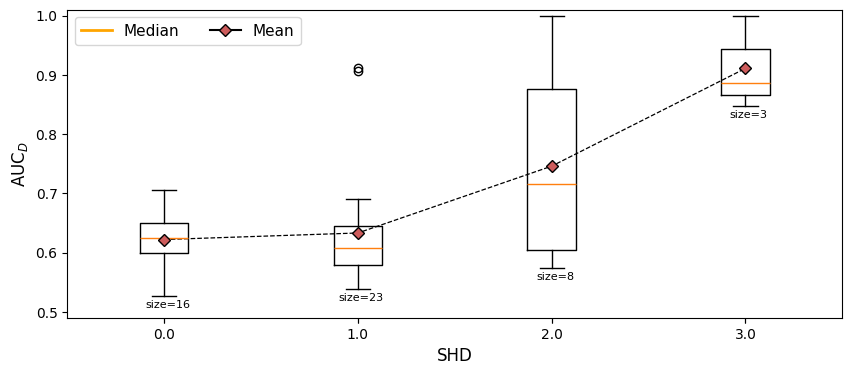

(40, 4)


In [106]:
# read data
res_df = pd.read_csv(archive_path / "misc" / "res_df_50.csv")

# plot
f, ax = plt.subplots(figsize=[10, 4])
ax.set_xticks(ticks=res_df['shd'].value_counts().sort_index().index)
ax.set_xlim((-0.5, 3.5))
ax.set_xlabel("SHD", fontsize=12)
ax.set_ylim((0.49, 1.01))
ax.set_ylabel("AUC$_D$", fontsize=12)
groups = res_df.groupby("shd")
means_xy = [[], []]
for shd in res_df['shd'].value_counts().sort_index().index: 
    group = groups.get_group(name=shd)
    box = ax.boxplot(x=group['auc_di'].to_numpy(), positions=[shd], widths=[0.25], 
                     showmeans=True, meanprops={'marker': 'D', 'markersize': 6, 'markeredgecolor': 'black','markerfacecolor': 'indianred'})
    means_xy[1].append(box['means'][0].get_ydata()[0])
    means_xy[0].append(box['means'][0].get_xdata()[0])
    caps_y = box['caps'][0].get_ydata()[0]
    caps_x = box['caps'][0].get_xdata()[0]
    ax.text(x=caps_x + 0.08, y=caps_y-0.015, s=f"size={group['auc_di'].shape[0]}", va="center", ha="center", fontsize=8)
ax.plot(means_xy[0], means_xy[1], color='black', linestyle="--", linewidth=0.9)
legend_elements = [Line2D([0], [0], color='orange', lw=2, label='Median'),
                   Line2D([0], [0], marker='D', color="black", markerfacecolor='indianred', markeredgecolor='black', markersize=6, label='Mean')]
ax.legend(handles=legend_elements, loc='upper left', ncols=2, fontsize=11)
plt.show()

print(res_df[res_df['auc_di']<0.7].shape)

### Debug

In [ ]:
toi_list = []
n2i_list = [] 
data_list_obs = []
data_list_int = []
res_df = pd.DataFrame(columns=["auc_do", "auc_di", "shd"])

for idx, (fn_ori, fn_sim) in enumerate(list(zip(
    os.listdir(archive_path / "tscm" / "ori"), 
    os.listdir(archive_path / "tscm" / "sim")
))[16:17]):
    print(f" ------------------------ {idx} ------------------------ ")
    
    # read original and simulated TSCMs
    with open(archive_path / "tscm" / "ori" / fn_ori, "rb") as f_ori:
        scm_ori = dill.load(f_ori)
    with open(archive_path / "tscm" / "sim" / fn_sim, "rb") as f_sim:
        scm_sim = dill.load(f_sim)

    # shd
    ori_graph, sim_graph = fix_lag_dim(
        a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
        b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
    )
    shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())
    print(f"LOG: SHD : {shd}")

    # observational data
    scm_ori._reset_time_series(init_history=scm_ori.time_series.loc[:3, :]) # NOTE: 3 is the maximum supported lag in the configuration search space
    scm_sim._reset_time_series(init_history=scm_ori.time_series.loc[:3, :])
    scm_ori.generate_time_series(n_samples=NS)
    scm_sim.generate_time_series(n_samples=NS)
    ts_ori_obs = scm_ori.time_series.copy()
    ts_sim_obs = scm_sim.time_series.copy()

    # time of intervention & pre-intervention data
    toi = int(0.50 * NS)
    ts_ori_pre = scm_ori.time_series.loc[:toi, :].copy()
    ts_sim_pre = scm_sim.time_series.loc[:toi, :].copy()

    # pre-intervention data & intervening nodes and values
    scm_ori.time_series = ts_ori_pre.copy()
    scm_sim.time_series = ts_sim_pre.copy() # NOTE: should scm_sim be initialized with the same values?
    n2is = np.random.choice(a=range(len(scm_ori.temp_nodes)), size=FNS, replace=False)
    for n2i in n2is:
        s2i = scm_ori.time_series.iloc[:, n2i]
        assert s2i.min()!=s2i.max(), f"ValueError: constant column {n2i}."
        scm_ori.temp_nodes[n2i].func = lambda x: s2i.min()
        scm_sim.temp_nodes[n2i].func = lambda x: s2i.min() # NOTE: intervening with the same value
        scm_ori.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)
        scm_sim.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)

    # post-intervention & interventional data 
    ts_ori_int = scm_ori.generate_time_series(n_samples=NS-toi).copy()
    ts_sim_int = scm_sim.generate_time_series(n_samples=NS-toi + 1).copy() # NOTE: +1 needed but why?
    ts_ori_post = scm_ori.time_series.loc[toi:, :].copy()
    ts_sim_post = scm_sim.time_series.loc[toi:, :].copy()

    # # plot & debug
    # f, ax = plt.subplots()
    # ax.plot(ts_ori_int.iloc[:, n2i], label="ori")
    # ax.plot(ts_sim_int.iloc[:, n2i], label="sim")
    # plt.show()

#     # monitoring
#     toi_list.append(toi)
#     n2i_list.append(n2i)
#     data_list_obs.append([ts_ori_obs, ts_sim_obs])
#     data_list_int.append([ts_ori_int, ts_sim_int])

#     """"  --------------------------------------------------------------------------------------------  """
    
    # evaluate
    auc_d_obs = run_detection_metrics(real=ts_ori_obs, synthetic=ts_sim_obs)["auc"]
    print(f"LOG: Discrimination AUC on observational data: {auc_d_obs}")
    auc_d_int = run_detection_metrics(real=ts_ori_int, synthetic=ts_sim_int)["auc"]
    print(f"LOG: Discrimination AUC on interventional data: {auc_d_int}")
    res_df.loc[idx] = [auc_d_obs, auc_d_int, shd]
    print()

    # evaluate
    auc_d_obs = run_detection_metrics(real=ts_ori_obs.loc[:, [col for col in ts_ori_obs.columns if col not in ["B", "G", "H"]]], 
                                      synthetic=ts_sim_obs.loc[:, [col for col in ts_sim_obs.columns if col not in ["B", "G", "H"]]])["auc"]
    print(f"LOG: Discrimination AUC on observational data: {auc_d_obs}")
    auc_d_int = run_detection_metrics(real=ts_ori_int.loc[:, [col for col in ts_ori_int.columns if col not in ["B", "G", "H"]]], 
                                      synthetic=ts_sim_int.loc[:, [col for col in ts_sim_int.columns if col not in ["B", "G", "H"]]])["auc"]
    print(f"LOG: Discrimination AUC on interventional data: {auc_d_int}")
    res_df.loc[idx] = [auc_d_obs, auc_d_int, shd]
    print()

In [ ]:
from scipy.stats import ks_2samp

adj_ori = minimal_adjacency(scm_ori.causal_structure.causal_structure_cp.clone())
adj_sim = minimal_adjacency(scm_sim.causal_structure.causal_structure_cp.clone())
edge_colors = {(i, j, k) : "darkred" if (adj_ori[i, j, k]==1 and adj_sim[i, j, k]==0) 
                                     else ("darkorange" if (adj_ori[i, j, k]==0 and adj_sim[i, j, k]==1) else "black")
                                     for i in range(adj_ori.shape[0])
                                     for j in range(adj_ori.shape[1])
                                     for k in range(adj_ori.shape[2])}
plot_adjacency(adj=adj_ori, size=6, edge_colors=edge_colors)
plot_adjacency(adj=adj_sim, size=6, edge_colors=edge_colors)

ori_graph, sim_graph = fix_lag_dim(
    a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
    b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
)
shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())
print(f"SHD : {shd}")

f, axs = plt.subplots(nrows=ts_ori_obs.shape[1], figsize=[5, 6])
for i, col in enumerate(ts_ori_obs.columns):
    # plot & debug
    axs[i].set_ylabel(col, fontdict={'size': 10, 'weight': 'demibold'})
    axs[i].set_xticks([], [])
    axs[i].set_yticks([], [])
    axs[i].plot(ts_ori_int.iloc[:, i], label="ori", color="teal")
    axs[i].plot(ts_sim_int.iloc[:, i], label="sim", color="chocolate")
    ks = ks_2samp(data1=ts_ori_int.iloc[:, i], data2=ts_sim_int.iloc[:, i])
    axs[i].set_ylim((
        min(ts_ori_int.iloc[:, i].min(), ts_sim_int.iloc[:, i].min()) - 0.15, 
        max(ts_ori_int.iloc[:, i].max(), ts_sim_int.iloc[:, i].max()) + 0.25
    ))
    axs[i].text(x=0.94, y=0.8, va='center', ha='center', s=f"KS={round(ks.statistic, 2)}", 
                fontdict={'size': 8, 'weight': 'roman'}, transform = axs[i].transAxes)
    # print(f"{col} : KS stat = {round(ks.statistic, 2)}")
    
legend_elements = [Line2D([0], [0], color='teal', lw=3, label='Original'),
                   Line2D([0], [0], color='chocolate', lw=3, label='Learned')]
f.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncols=2)

# f.suptitle("Interventional time-series data per column : Original vs Learned", fontsize="10")
f.tight_layout()
plt.show()



##### Elaborated Plot

In [ ]:
# f = plt.figure(figsize=(18, 9))
# gs = plt.GridSpec(nrows=10, ncols=3)

# # subplots
# ax1 = f.add_subplot(gs[:5, 0])
# ax2 = f.add_subplot(gs[5:, 0])

# # -- ax 1 -- 
# # parameters
# adj = scm_ori.causal_structure.causal_structure_cp.clone()
# n_vars = adj.shape[0]
# n_lags = adj.shape[2]
# circle_radius = 1/(2*n_vars)
# circle_outline_color = "black"
# circle_fill_color = "white"
# fontsize = circle_radius * 200
# # x-positions
# x_incr = (1-(circle_radius*3)) / (n_lags)
# x_positions = {lag: circle_radius*(3/2) + x_incr*lag for lag in range(n_lags + 1)}
# # y-positions
# y_incr = (1-(circle_radius*3)) / (n_vars-1)
# y_positions = {var: 1 - (circle_radius*(3/2) + y_incr*var) for var in range(n_vars)}
# # node names
# node_names = {lag: ["_".join([x, "{"+"t"+"}"]) if lag==n_lags else "_".join([x, "{"+f"t-{n_lags-lag}"+"}"]) 
#                     for x in COL_NAMES[:n_vars]] for lag in range(n_lags+1)}
# # node loop 
# for k in range(n_lags + 1):
#     for i in range(n_vars):
#         # Add circles to the plot
#         xy = (x_positions[k], y_positions[i])
#         circle1 = mpatches.Circle(xy=xy, radius=circle_radius, color=circle_fill_color, ec=circle_outline_color, zorder=3, transform=ax1.transAxes)
#         ax1.add_patch(circle1)
#         ax1.annotate(f"${node_names[k][i]}$", xy=xy, fontsize=fontsize, va='center', ha='center')
# # edge loop
# for k in range(n_lags): 
#     for i in range(n_vars):
#         for j in range(n_vars):
#             if adj[i, j, k] == 1:
#                 # draw edge
#                 xy_source = (x_positions[k] + circle_radius, y_positions[j]) # source : B_t-2
#                 xy_target = (x_positions[adj.shape[2]] - circle_radius, y_positions[i]) # target : A_t
#                 arrow = mpatches.FancyArrowPatch(
#                     posA=xy_source,       
#                     posB=xy_target,       
#                     shrinkA=1.5,  
#                     shrinkB=2.5,  
#                     linewidth=0.8,
#                     arrowstyle="-|>",     
#                     mutation_scale=10,
#                     connectionstyle="arc3",
#                     color=edge_colors[(i, j, k)] if (i, j, k) in edge_colors.keys() else "black",
#                     # color='darkred',
#                     alpha=1,
#                     zorder=2, 
#                     transform=ax1.transAxes
#                 )
#                 ax1.add_patch(arrow)
# # limits and aspect ratio
# ax1.set_xticks([], [])
# ax1.set_yticks([], [])
# ax1.axis("off")
# ax1.set_aspect('equal', adjustable='box')

# # -- ax 2 -- 
# # parameters
# adj = scm_sim.causal_structure.causal_structure_cp.clone()
# # node loop 
# for k in range(n_lags + 1):
#     for i in range(n_vars):
#         # Add circles to the plot
#         xy = (x_positions[k], y_positions[i])
#         circle1 = mpatches.Circle(xy=xy, radius=circle_radius, color=circle_fill_color, ec=circle_outline_color, zorder=3, transform=ax2.transAxes)
#         ax2.add_patch(circle1)
#         ax2.annotate(f"${node_names[k][i]}$", xy=xy, fontsize=fontsize, va='center', ha='center')
# # edge loop
# for k in range(n_lags): 
#     for i in range(n_vars):
#         for j in range(n_vars):
#             if adj[i, j, k] == 1:
#                 # draw edge
#                 xy_source = (x_positions[k] + circle_radius, y_positions[j]) # source : B_t-2
#                 xy_target = (x_positions[adj.shape[2]] - circle_radius, y_positions[i]) # target : A_t
#                 arrow = mpatches.FancyArrowPatch(
#                     posA=xy_source,       
#                     posB=xy_target,       
#                     shrinkA=1.5,  
#                     shrinkB=2.5,  
#                     linewidth=0.8,
#                     arrowstyle="-|>",     
#                     mutation_scale=10,
#                     connectionstyle="arc3",
#                     color=edge_colors[(i, j, k)] if (i, j, k) in edge_colors.keys() else "black",
#                     # color='darkred',
#                     alpha=1,
#                     zorder=2, 
#                     transform=ax2.transAxes
#                 )
#                 ax2.add_patch(arrow)
# # limits and aspect ratio
# ax2.set_xticks([], [])
# ax2.set_yticks([], [])
# ax2.axis("off")
# ax2.set_aspect('equal', adjustable='box')
# # ax2.set_xlabel("(original)")


# # -- ax 3 --
# ax3s = []
# for i, col in enumerate(ts_ori_obs.columns):
#     ax3 = f.add_subplot(gs[i:i+1, 1:])
#     ax3s.append(ax3)
#     # plot & debug
#     ax3.set_ylabel(col, fontdict={'size': 12, 'weight': 'demibold'})
#     ax3.set_xticks([], [])
#     ax3.set_yticks([], [])
#     ax3.plot(ts_ori_int.iloc[:, i], label="ori", color="teal")
#     ax3.plot(ts_sim_int.iloc[:, i], label="sim", color="chocolate")
#     ks = ks_2samp(data1=ts_ori_int.iloc[:, i], data2=ts_sim_int.iloc[:, i])
#     ax3.set_ylim((
#         min(ts_ori_int.iloc[:, i].min(), ts_sim_int.iloc[:, i].min()) - 0.15, 
#         max(ts_ori_int.iloc[:, i].max(), ts_sim_int.iloc[:, i].max()) + 0.25
#     ))
#     ax3.text(x=0.94, y=0.8, va='center', ha='center', s=f"KS={round(ks.statistic, 2)}", 
#                 fontdict={'size': 12, 'weight': 'roman'}, transform = ax3.transAxes)
#     # print(f"{col} : KS stat = {round(ks.statistic, 2)}")
    
# legend_elements = [Line2D([0], [0], color='teal', lw=3, label='Original'),
#                    Line2D([0], [0], color='chocolate', lw=3, label='Learned')]
# ax3s[0].legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.65), ncols=2, fontsize=14)

# f.tight_layout()
# f.subplots_adjust(wspace=0, hspace=0)
# plt.show()

### Archive

In [ ]:
# toi_list = {}
# n2i_list = {} 
# auc_list_obs = {}
# auc_list_int = {}
# data_list_obs = {}
# data_list_int = {}
# res_df = pd.DataFrame(columns=["auc_do", "auc_di", "shd"])

# for idx, (fn_ori, fn_sim) in enumerate(list(zip(
#     os.listdir(archive_path / "tscm" / "ori"), 
#     os.listdir(archive_path / "tscm" / "sim")
# ))[:]):
#     print(f" ------------------------ {idx} ------------------------ ")
    
#     # read original and simulated TSCMs
#     with open(archive_path / "tscm" / "ori" / fn_ori, "rb") as f_ori:
#         scm_ori = dill.load(f_ori)
#     with open(archive_path / "tscm" / "sim" / fn_sim, "rb") as f_sim:
#         scm_sim = dill.load(f_sim)

#     # shd
#     ori_graph, sim_graph = fix_lag_dim(
#         a_graph=scm_ori.causal_structure.causal_structure_cp.clone(), 
#         b_graph=scm_sim.causal_structure.causal_structure_cp.clone()
#     )
#     shd = SHD(target=ori_graph.numpy(), pred=sim_graph.numpy())

#     # monitoring
#     toi_list[idx] = []
#     n2i_list[idx] = []
#     auc_list_obs[idx] = []
#     auc_list_int[idx] = []
#     data_list_obs[idx] = []
#     data_list_int[idx] = []

#     for idy in range(10):
#         print(f" --- idx={idx} | idy={idy} --- ")
        
#         # observational data
#         scm_ori._reset_time_series(init_history=scm_ori.time_series.loc[:3, :]) # NOTE: 3 is the maximum supported lag in the configuration search space
#         scm_sim._reset_time_series(init_history=scm_ori.time_series.loc[:3, :])
#         scm_ori.generate_time_series(n_samples=NS)
#         scm_sim.generate_time_series(n_samples=NS)
#         ts_ori_obs = scm_ori.time_series.copy()
#         ts_sim_obs = scm_sim.time_series.copy()

#         # time of intervention & pre-intervention data
#         toi = np.random.randint(low=int(0.50 * NS), high=int(0.51 * NS))
#         ts_ori_pre = scm_ori.time_series.loc[:toi, :].copy()
#         ts_sim_pre = scm_sim.time_series.loc[:toi, :].copy()

#         # pre-intervention data & intervening nodes and values
#         scm_ori.time_series = ts_ori_pre.copy()
#         scm_sim.time_series = ts_sim_pre.copy() # NOTE: should scm_sim be initialized with the same values?
#         n2is = np.random.choice(a=range(len(scm_ori.temp_nodes)), size=FNS, replace=False)
#         for n2i in n2is:
#             s2i = scm_ori.time_series.iloc[:, n2i]
#             assert s2i.min()!=s2i.max(), f"ValueError: constant column {n2i}."
#             # hard-intervention with constant value
#             scm_ori.temp_nodes[n2i].func = lambda x: s2i.min()
#             scm_sim.temp_nodes[n2i].func = lambda x: s2i.min() # NOTE: intervening with the same value 
#             scm_ori.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)
#             scm_sim.temp_nodes[n2i].z_distribution = torch.distributions.normal.Normal(loc=0, scale=1e-5)

#         # post-intervention & interventional data 
#         ts_ori_int = scm_ori.generate_time_series(n_samples=NS-toi).copy()
#         ts_sim_int = scm_sim.generate_time_series(n_samples=NS-toi + 1).copy() # NOTE: +1 needed but why?
#         ts_ori_post = scm_ori.time_series.loc[toi:, :].copy()
#         ts_sim_post = scm_sim.time_series.loc[toi:, :].copy()

#         # monitoring
#         toi_list[idx].append(toi)
#         n2i_list[idx].append(n2i)
#         data_list_obs[idx].append([ts_ori_obs, ts_sim_obs])
#         data_list_int[idx].append([ts_ori_int, ts_sim_int])

#         """"  --------------------------------------------------------------------------------------------  """
        
#         # evaluate
#         auc_d_obs = run_detection_metrics(real=ts_ori_obs, synthetic=ts_sim_obs)["auc"]
#         print(f"LOG: Discrimination AUC on observational data: {auc_d_obs}")
#         auc_d_int = run_detection_metrics(real=ts_ori_int, synthetic=ts_sim_int)["auc"]
#         print(f"LOG: Discrimination AUC on interventional data: {auc_d_int}")
#         print()
#         auc_list_obs[idx].append(np.round(auc_d_obs, 2))
#         auc_list_int[idx].append(np.round(auc_d_int, 2))

#     res_df.loc[idx] = [np.mean(auc_list_obs[idx]).round(2), np.mean(auc_list_int[idx]).round(2), shd]
